# GraphRAG Output Inspector

This notebook helps you explore and visualize the results from your GraphRAG knowledge graph extraction process. We'll examine entities, relationships, communities, and community reports generated from your data.

## Import Required Libraries

First, let's import all the necessary libraries for data manipulation and visualization.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Entities Data

Let's load the entities extracted from your knowledge graph. These represent the key concepts, people, places, and objects identified in your documents.

In [17]:
# Load the entities table
try:
    df_entities = pd.read_parquet('output/entities.parquet')
    print(f"✅ Successfully loaded entities data!")
    print(f"📊 Shape: {df_entities.shape[0]} entities with {df_entities.shape[1]} columns")
    print(f"📋 Columns: {list(df_entities.columns)}")
except FileNotFoundError:
    print("❌ Could not find output/entities.parquet")
    print("Make sure you've run the GraphRAG indexing process first.")
except Exception as e:
    print(f"❌ Error loading entities: {e}")

✅ Successfully loaded entities data!
📊 Shape: 4 entities with 10 columns
📋 Columns: ['id', 'human_readable_id', 'title', 'type', 'description', 'text_unit_ids', 'frequency', 'degree', 'x', 'y']


## Display Entities Overview

Let's examine the structure and content of the entities data.

In [18]:
# Display the first few rows of entities
if 'df_entities' in locals():
    print("🔍 First 5 entities:")
    display(df_entities.head())
    
    print("\n📋 Dataset Info:")
    print(f"Total entities: {len(df_entities)}")
    
    # Check for common columns and display relevant info
    if 'type' in df_entities.columns:
        print(f"\n🏷️ Entity types:")
        print(df_entities['type'].value_counts())
    
    if 'title' in df_entities.columns:
        print(f"\n📝 Sample entity titles:")
        print(df_entities['title'].head(10).tolist())
    
    if 'description' in df_entities.columns:
        print(f"\n📖 Sample descriptions (first 3):")
        for i, desc in enumerate(df_entities['description'].head(3)):
            if pd.notna(desc):
                print(f"{i+1}. {desc[:200]}{'...' if len(str(desc)) > 200 else ''}")
else:
    print("❌ Entities data not loaded. Please run the previous cell first.")

🔍 First 5 entities:


,id,human_readable_id,title,type,description,text_unit_ids,frequency,degree,x,y
0,ca2fe782-9490-4d63-9f06-9d348a28c5f5,0,DR. AMELIA RODRÍGUEZ,PERSON,"Dr. Amelia Rodríguez is an environmental engineer from Barcelona, Spain, who founded GreenVolt E...",[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...,1,2,0,0
1,d76d5705-b69c-425c-b4a9-df0e592737d1,1,GREENVOLT ENERGY,ORGANIZATION,GreenVolt Energy is a startup founded by Dr. Amelia Rodríguez that focuses on developing afforda...,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...,1,3,0,0
2,51c3de6f-7f84-4432-83cb-7fe886315553,2,BARCELONA,GEO,Barcelona is a city in Spain where Dr. Amelia Rodríguez is based and where GreenVolt Energy was ...,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...,1,1,0,0
3,0e615edf-0d74-49da-93ff-cc75a548531e,3,SPAIN,,,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...,1,2,0,0



📋 Dataset Info:
Total entities: 4

🏷️ Entity types:
type
PERSON          1
ORGANIZATION    1
GEO             1
                1
Name: count, dtype: int64

📝 Sample entity titles:
['DR. AMELIA RODRÍGUEZ', 'GREENVOLT ENERGY', 'BARCELONA', 'SPAIN']

📖 Sample descriptions (first 3):
1. Dr. Amelia Rodríguez is an environmental engineer from Barcelona, Spain, who founded GreenVolt Energy in 2010.
2. GreenVolt Energy is a startup founded by Dr. Amelia Rodríguez that focuses on developing affordable solar panels for rural communities.
3. Barcelona is a city in Spain where Dr. Amelia Rodríguez is based and where GreenVolt Energy was founded.


## Load Community Reports

Community reports contain high-level summaries of different communities (clusters) found in your knowledge graph.

In [19]:
# Load the community reports
try:
    df_reports = pd.read_parquet('output/community_reports.parquet')
    print(f"✅ Successfully loaded community reports!")
    print(f"📊 Shape: {df_reports.shape[0]} reports with {df_reports.shape[1]} columns")
    print(f"📋 Columns: {list(df_reports.columns)}")
except FileNotFoundError:
    print("❌ Could not find output/community_reports.parquet")
    print("Make sure you've run the GraphRAG indexing process first.")
except Exception as e:
    print(f"❌ Error loading community reports: {e}")

# Also load communities data if available
try:
    df_communities = pd.read_parquet('output/communities.parquet')
    print(f"✅ Successfully loaded communities data!")
    print(f"📊 Shape: {df_communities.shape[0]} communities with {df_communities.shape[1]} columns")
except FileNotFoundError:
    print("❌ Could not find output/communities.parquet")
except Exception as e:
    print(f"❌ Error loading communities: {e}")

✅ Successfully loaded community reports!
📊 Shape: 1 reports with 15 columns
📋 Columns: ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'summary', 'full_content', 'rank', 'rating_explanation', 'findings', 'full_content_json', 'period', 'size']
✅ Successfully loaded communities data!
📊 Shape: 1 communities with 12 columns


## Display Community Report Content

Let's examine the community reports to understand the high-level insights from your knowledge graph.

In [20]:
# Display community reports
if 'df_reports' in locals():
    print("📋 Community Reports Overview:")
    display(df_reports.head())
    
    # Display the first community report's full content
    if 'full_content' in df_reports.columns and len(df_reports) > 0:
        print("\n📖 First Community Report Content:")
        print("=" * 80)
        first_report = df_reports['full_content'].iloc[0]
        if pd.notna(first_report):
            print(first_report)
        else:
            print("No content available for the first report")
        print("=" * 80)
    
    # Show summary statistics
    if 'title' in df_reports.columns:
        print(f"\n📊 Number of community reports: {len(df_reports)}")
        print("\n🏷️ Community titles:")
        for i, title in enumerate(df_reports['title'].head(5)):
            if pd.notna(title):
                print(f"{i+1}. {title}")
else:
    print("❌ Community reports data not loaded. Please run the previous cell first.")

📋 Community Reports Overview:


,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,ba4c519d610d490ba9fc6b95ec3b784d,0,0,0,-1,[],GreenVolt Energy and Dr. Amelia Rodríguez,"The community centers around Dr. Amelia Rodríguez, an environmental engineer who founded GreenVo...",# GreenVolt Energy and Dr. Amelia Rodríguez\n\nThe community centers around Dr. Amelia Rodríguez...,7.5,The impact severity rating is high due to the potential for significant positive change in energ...,"[{'explanation': 'Dr. Amelia Rodríguez is a pivotal figure in this community, being the founder ...","{\n ""title"": ""GreenVolt Energy and Dr. Amelia Rodríguez"",\n ""summary"": ""The community cent...",2026-01-11,4



📖 First Community Report Content:
# GreenVolt Energy and Dr. Amelia Rodríguez

The community centers around Dr. Amelia Rodríguez, an environmental engineer who founded GreenVolt Energy in Barcelona, Spain. The organization focuses on developing affordable solar panels for rural communities, highlighting its commitment to sustainable energy solutions. The relationships between Dr. Rodríguez, GreenVolt Energy, and the city of Barcelona illustrate a cohesive network aimed at addressing energy challenges in rural areas.

## Dr. Amelia Rodríguez's leadership

Dr. Amelia Rodríguez is a pivotal figure in this community, being the founder of GreenVolt Energy. Her background as an environmental engineer positions her as a knowledgeable leader in the renewable energy sector. The establishment of GreenVolt Energy under her guidance reflects her commitment to addressing energy accessibility issues, particularly in rural communities. This leadership role is crucial for the organization's direction

## Load Relationships Data

Let's also examine the relationships between entities in your knowledge graph.

In [21]:
# Load relationships
try:
    df_relationships = pd.read_parquet('output/relationships.parquet')
    print(f"✅ Successfully loaded relationships data!")
    print(f"📊 Shape: {df_relationships.shape[0]} relationships with {df_relationships.shape[1]} columns")
    print(f"📋 Columns: {list(df_relationships.columns)}")
    
    # Display sample relationships
    print("\n🔗 Sample relationships:")
    display(df_relationships.head())
    
    if 'description' in df_relationships.columns:
        print("\n📖 Sample relationship descriptions:")
        for i, desc in enumerate(df_relationships['description'].head(3)):
            if pd.notna(desc):
                print(f"{i+1}. {desc}")
                
except FileNotFoundError:
    print("❌ Could not find output/relationships.parquet")
except Exception as e:
    print(f"❌ Error loading relationships: {e}")

✅ Successfully loaded relationships data!
📊 Shape: 4 relationships with 8 columns
📋 Columns: ['id', 'human_readable_id', 'source', 'target', 'description', 'weight', 'combined_degree', 'text_unit_ids']

🔗 Sample relationships:


,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
0,bac302a4-70c9-4217-bcda-dd12e6bfa709,0,DR. AMELIA RODRÍGUEZ,GREENVOLT ENERGY,Dr. Amelia Rodríguez founded GreenVolt Energy to develop solar panels for rural communities,8.0,5,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...
1,83b660d2-ca59-4988-9897-033f59bfa1b7,1,DR. AMELIA RODRÍGUEZ,SPAIN,"Dr. Amelia Rodríguez is from Spain, where she founded GreenVolt Energy",6.0,4,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...
2,39b29202-52e5-4026-ad27-40036307726c,2,GREENVOLT ENERGY,BARCELONA,"GreenVolt Energy was founded in Barcelona, Spain by Dr. Amelia Rodríguez",1.0,4,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...
3,a9a63b21-47d4-4192-b6ae-c944b19e123d,3,GREENVOLT ENERGY,SPAIN,"GreenVolt Energy operates in Spain, focusing on solar panel development",1.0,5,[5bc771a4c3d610805aaf177905b7b1bc4c37965560811ecaf28d8cab0dc4c9d9f61e2df7d3bc79060d3cc29313ef4aa...



📖 Sample relationship descriptions:
1. Dr. Amelia Rodríguez founded GreenVolt Energy to develop solar panels for rural communities
2. Dr. Amelia Rodríguez is from Spain, where she founded GreenVolt Energy
3. GreenVolt Energy was founded in Barcelona, Spain by Dr. Amelia Rodríguez


## Visualize Entity Statistics

Let's create some visualizations to better understand the distribution and characteristics of entities in your graph.

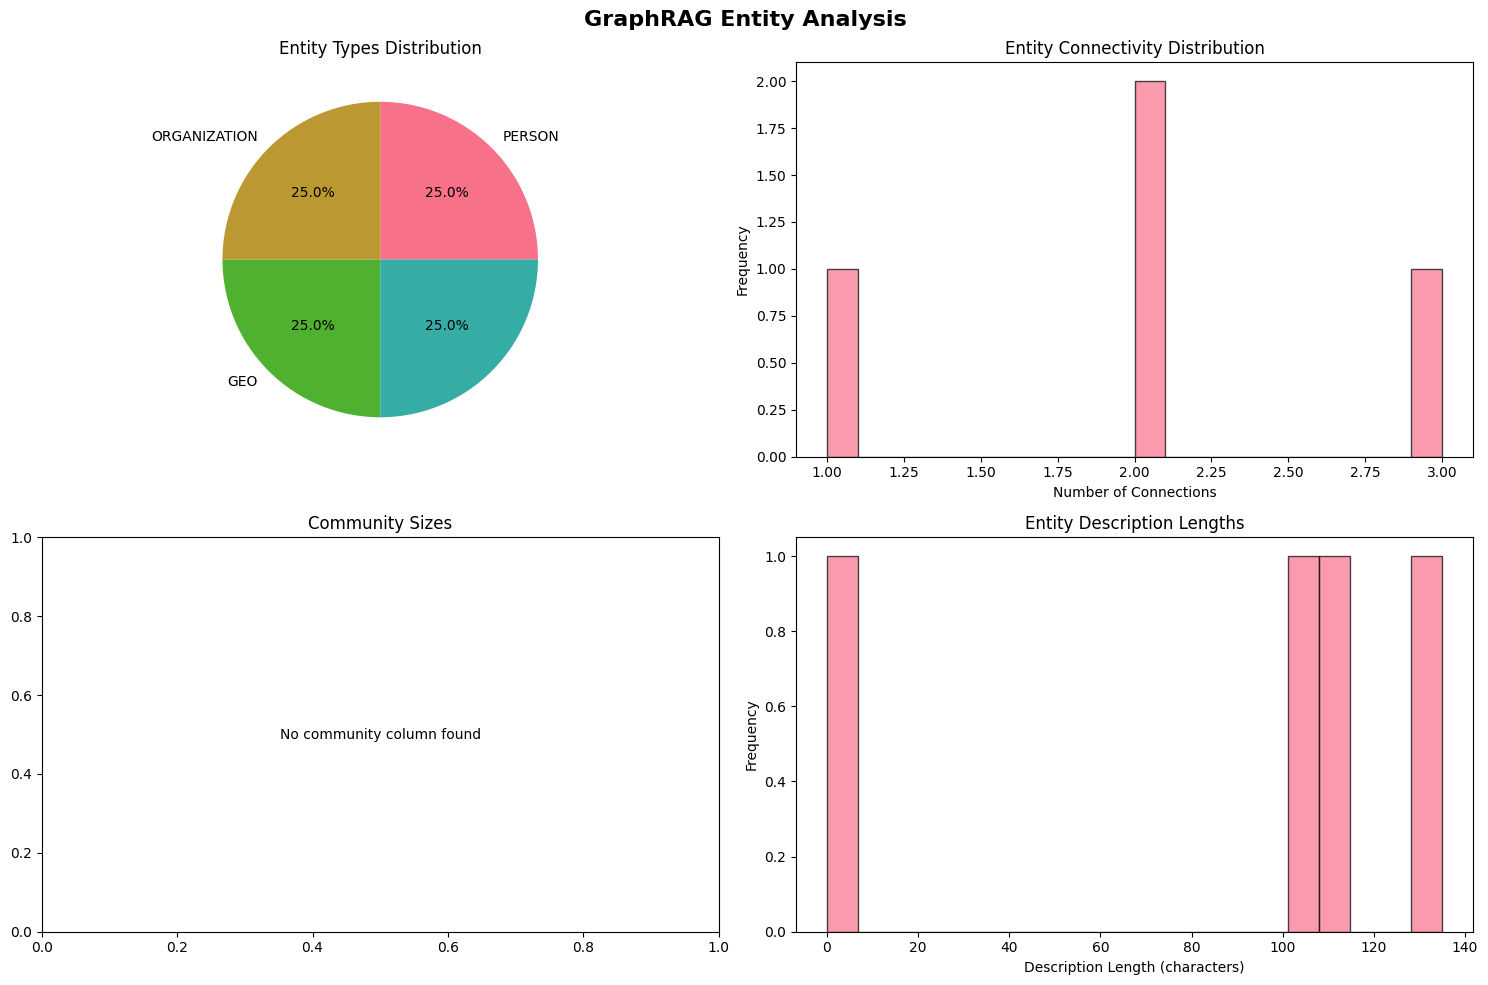

📊 Summary Statistics:
   • Total entities: 4
   • Unique entity types: 4
   • Total relationships: 4


In [22]:
# Create visualizations for entity statistics
if 'df_entities' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('GraphRAG Entity Analysis', fontsize=16, fontweight='bold')
    
    # 1. Entity types distribution
    if 'type' in df_entities.columns:
        type_counts = df_entities['type'].value_counts().head(10)
        axes[0, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
        axes[0, 0].set_title('Entity Types Distribution')
    else:
        axes[0, 0].text(0.5, 0.5, 'No type column found', ha='center', va='center')
        axes[0, 0].set_title('Entity Types Distribution')
    
    # 2. Entity degree (if we have relationships)
    if 'df_relationships' in locals():
        # Count entity connections
        source_counts = df_relationships['source'].value_counts() if 'source' in df_relationships.columns else pd.Series()
        target_counts = df_relationships['target'].value_counts() if 'target' in df_relationships.columns else pd.Series()
        
        if not source_counts.empty and not target_counts.empty:
            total_connections = source_counts.add(target_counts, fill_value=0)
            axes[0, 1].hist(total_connections.values, bins=20, edgecolor='black', alpha=0.7)
            axes[0, 1].set_title('Entity Connectivity Distribution')
            axes[0, 1].set_xlabel('Number of Connections')
            axes[0, 1].set_ylabel('Frequency')
        else:
            axes[0, 1].text(0.5, 0.5, 'No relationship data found', ha='center', va='center')
            axes[0, 1].set_title('Entity Connectivity Distribution')
    else:
        axes[0, 1].text(0.5, 0.5, 'No relationship data loaded', ha='center', va='center')
        axes[0, 1].set_title('Entity Connectivity Distribution')
    
    # 3. Community membership (if available)
    if 'community' in df_entities.columns:
        community_sizes = df_entities['community'].value_counts().head(15)
        axes[1, 0].bar(range(len(community_sizes)), community_sizes.values)
        axes[1, 0].set_title('Community Sizes (Top 15)')
        axes[1, 0].set_xlabel('Community ID')
        axes[1, 0].set_ylabel('Number of Entities')
        axes[1, 0].tick_params(axis='x', rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, 'No community column found', ha='center', va='center')
        axes[1, 0].set_title('Community Sizes')
    
    # 4. Description lengths (if available)
    if 'description' in df_entities.columns:
        desc_lengths = df_entities['description'].dropna().str.len()
        axes[1, 1].hist(desc_lengths, bins=20, edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Entity Description Lengths')
        axes[1, 1].set_xlabel('Description Length (characters)')
        axes[1, 1].set_ylabel('Frequency')
    else:
        axes[1, 1].text(0.5, 0.5, 'No description column found', ha='center', va='center')
        axes[1, 1].set_title('Entity Description Lengths')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"📊 Summary Statistics:")
    print(f"   • Total entities: {len(df_entities)}")
    if 'type' in df_entities.columns:
        print(f"   • Unique entity types: {df_entities['type'].nunique()}")
    if 'community' in df_entities.columns:
        print(f"   • Number of communities: {df_entities['community'].nunique()}")
    if 'df_relationships' in locals():
        print(f"   • Total relationships: {len(df_relationships)}")
        
else:
    print("❌ Entities data not loaded. Please run the entity loading cell first.")

## Create Graph Visualization

Let's create a network visualization to see the actual graph structure. We'll use NetworkX for creating the graph and Matplotlib for visualization.

🎨 Creating network visualization...


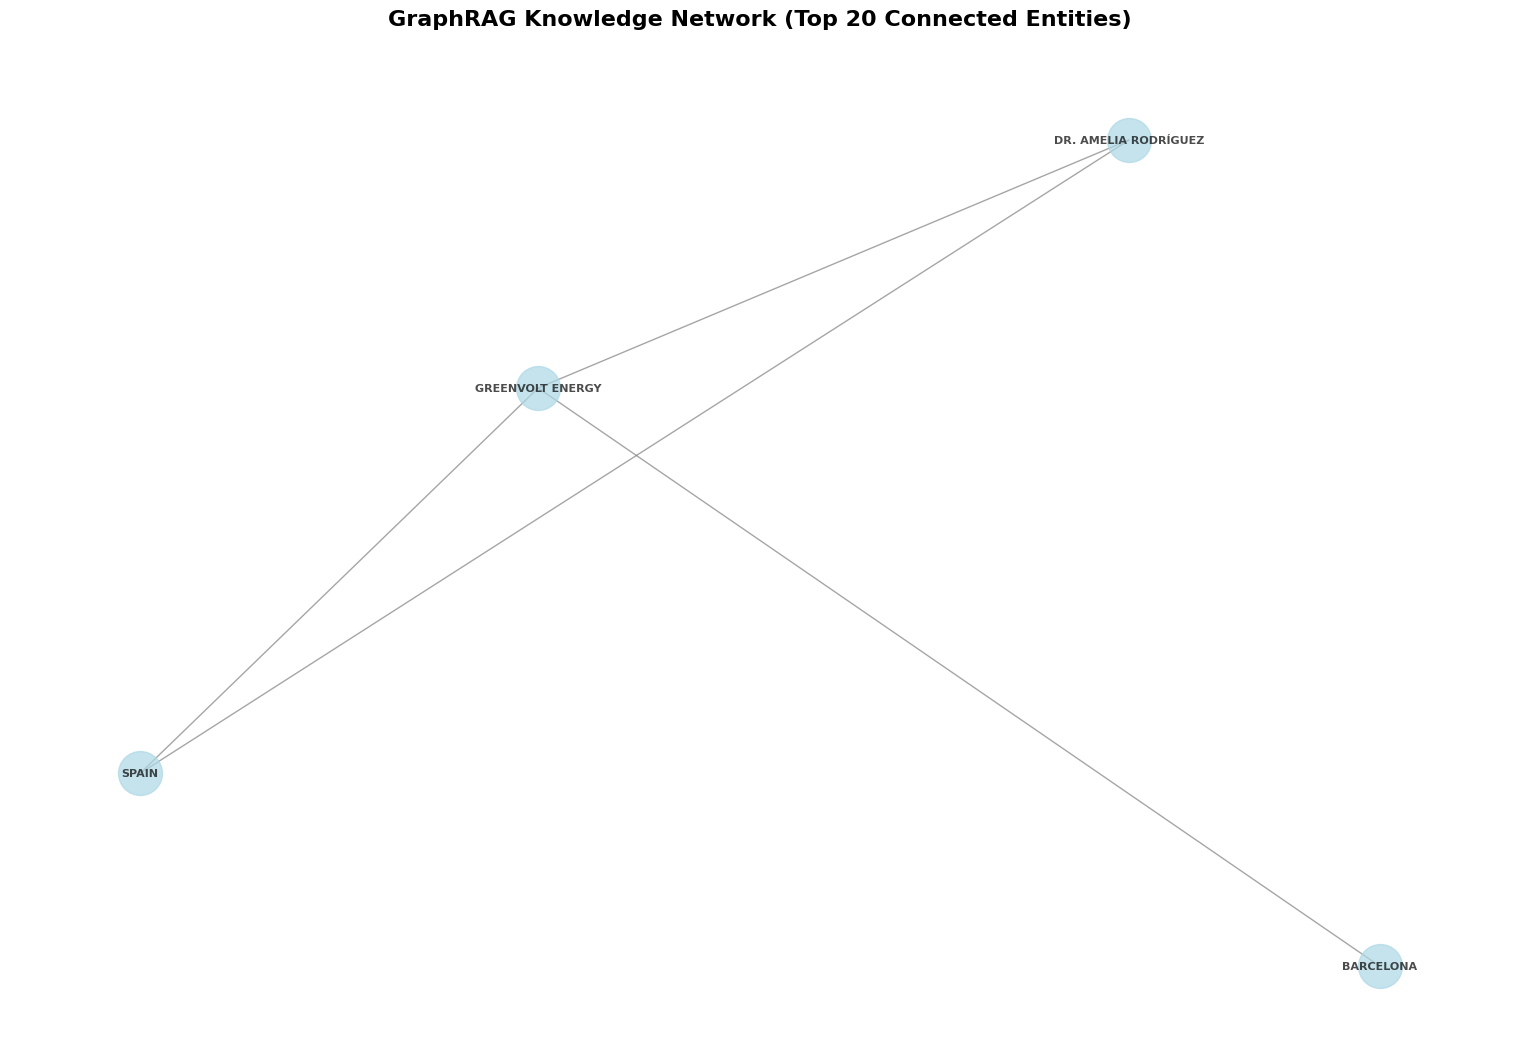


🔗 Network Statistics:
   • Nodes in visualization: 4
   • Edges in visualization: 4
   • Average degree: 2.00

⭐ Most connected entities in visualization:
   • GREENVOLT ENERGY: 3 connections
   • DR. AMELIA RODRÍGUEZ: 2 connections
   • SPAIN: 2 connections
   • BARCELONA: 1 connections


In [23]:
# Install networkx if not available
try:
    import networkx as nx
except ImportError:
    print("Installing networkx...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'networkx'])
    import networkx as nx

# Create network visualization
if 'df_entities' in locals() and 'df_relationships' in locals():
    # Create a sample graph with limited nodes for visualization
    print("🎨 Creating network visualization...")
    
    # Limit to top entities by degree for better visualization
    if 'source' in df_relationships.columns and 'target' in df_relationships.columns:
        # Count entity connections
        source_counts = df_relationships['source'].value_counts()
        target_counts = df_relationships['target'].value_counts()
        total_connections = source_counts.add(target_counts, fill_value=0)
        
        # Get top connected entities
        top_entities = total_connections.head(20).index.tolist()
        
        # Filter relationships to only include top entities
        filtered_rels = df_relationships[
            (df_relationships['source'].isin(top_entities)) & 
            (df_relationships['target'].isin(top_entities))
        ].head(30)  # Limit to 30 relationships for clarity
        
        # Create the graph
        G = nx.from_pandas_edgelist(
            filtered_rels, 
            source='source', 
            target='target',
            edge_attr='description' if 'description' in filtered_rels.columns else None
        )
        
        # Create the visualization
        plt.figure(figsize=(15, 10))
        
        # Calculate layout
        pos = nx.spring_layout(G, k=3, iterations=50)
        
        # Draw the network
        nx.draw(G, pos, 
               with_labels=True, 
               node_color='lightblue',
               node_size=1000,
               font_size=8,
               font_weight='bold',
               edge_color='gray',
               alpha=0.7)
        
        plt.title("GraphRAG Knowledge Network (Top 20 Connected Entities)", 
                 fontsize=16, fontweight='bold', pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Network statistics
        print(f"\n🔗 Network Statistics:")
        print(f"   • Nodes in visualization: {G.number_of_nodes()}")
        print(f"   • Edges in visualization: {G.number_of_edges()}")
        print(f"   • Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
        
        # Show most connected entities
        degrees = dict(G.degree())
        sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
        print(f"\n⭐ Most connected entities in visualization:")
        for entity, degree in sorted_degrees[:5]:
            print(f"   • {entity}: {degree} connections")
    else:
        print("❌ Could not find source/target columns in relationships data")
else:
    print("❌ Need both entities and relationships data for network visualization")
    print("Please make sure both datasets are loaded.")

## Interactive Entity Search

Let's create a simple search function to explore specific entities and their connections.

In [24]:
def search_entity(search_term, max_results=10):
    """Search for entities by name and show their details and connections."""
    if 'df_entities' not in locals() or 'df_entities' not in globals():
        print("❌ Entities data not loaded. Please run the data loading cells first.")
        return
    
    # Search in entity titles/names
    if 'title' in df_entities.columns:
        mask = df_entities['title'].str.contains(search_term, case=False, na=False)
    elif 'name' in df_entities.columns:
        mask = df_entities['name'].str.contains(search_term, case=False, na=False)
    else:
        print("❌ No title or name column found in entities data")
        return
    
    results = df_entities[mask].head(max_results)
    
    if len(results) == 0:
        print(f"🔍 No entities found matching '{search_term}'")
        return
    
    print(f"🔍 Found {len(results)} entities matching '{search_term}':")
    print("=" * 80)
    
    for idx, entity in results.iterrows():
        title_col = 'title' if 'title' in df_entities.columns else 'name'
        print(f"\n📌 {entity[title_col]}")
        
        if 'type' in entity and pd.notna(entity['type']):
            print(f"   Type: {entity['type']}")
        
        if 'description' in entity and pd.notna(entity['description']):
            desc = str(entity['description'])[:200]
            print(f"   Description: {desc}{'...' if len(str(entity['description'])) > 200 else ''}")
        
        # Show relationships if available
        if 'df_relationships' in locals() or 'df_relationships' in globals():
            entity_name = entity[title_col]
            if 'source' in df_relationships.columns and 'target' in df_relationships.columns:
                related = df_relationships[
                    (df_relationships['source'] == entity_name) | 
                    (df_relationships['target'] == entity_name)
                ]
                
                if len(related) > 0:
                    print(f"   🔗 Connected to {len(related)} other entities")
                    # Show a few connections
                    for _, rel in related.head(3).iterrows():
                        other_entity = rel['target'] if rel['source'] == entity_name else rel['source']
                        rel_desc = rel['description'] if 'description' in rel and pd.notna(rel['description']) else "connected to"
                        print(f"      → {other_entity} ({rel_desc})")
        
        print("-" * 40)

# Example usage
print("🔍 Entity Search Function Ready!")
print("Use: search_entity('your_search_term') to search for entities")
print("\nTry searching for common terms that might appear in your data:")

# Show some sample entity names for searching
if 'df_entities' in locals():
    title_col = 'title' if 'title' in df_entities.columns else ('name' if 'name' in df_entities.columns else None)
    if title_col:
        sample_entities = df_entities[title_col].dropna().head(5).tolist()
        print(f"Sample entities to search: {sample_entities}")
        
        # Automatically search for the first entity as an example
        if sample_entities:
            first_entity_word = sample_entities[0].split()[0] if sample_entities[0] else ""
            if first_entity_word:
                print(f"\n🎯 Example search for '{first_entity_word}':")
                search_entity(first_entity_word, max_results=3)

🔍 Entity Search Function Ready!
Use: search_entity('your_search_term') to search for entities

Try searching for common terms that might appear in your data:
Sample entities to search: ['DR. AMELIA RODRÍGUEZ', 'GREENVOLT ENERGY', 'BARCELONA', 'SPAIN']

🎯 Example search for 'DR.':
❌ Entities data not loaded. Please run the data loading cells first.


## Export to Neo4j Graph Database

Now let's export your GraphRAG data to Neo4j for advanced graph visualization and analysis. This gives you the power of Cypher queries and Neo4j's graph algorithms.

In [1]:
# Check if Neo4j driver is available
try:
    from neo4j import GraphDatabase
    print("✅ Neo4j driver is installed and ready")
    neo4j_available = True
except ImportError:
    print("❌ Neo4j driver not installed")
    print("Run this command to install it: pip install neo4j")
    neo4j_available = False

if neo4j_available:
    print("\n🚀 Neo4j Import Options:")
    print("1. 📄 Use the import_neo4j.py script (recommended)")
    print("2. 💻 Run import directly from this notebook")
    print("\n📋 Prerequisites:")
    print("   • Neo4j running on localhost:7687 (or update the URI)")
    print("   • Valid username/password (default: neo4j/your_password)")
    
    print(f"\n📊 Your data ready for Neo4j:")
    if 'df_entities' in locals():
        print(f"   • {len(df_entities)} entities")
    if 'df_relationships' in locals():
        print(f"   • {len(df_relationships)} relationships")  
    if 'df_reports' in locals():
        print(f"   • {len(df_reports)} community reports")
        
    print(f"\n💡 Next steps:")
    print(f"   1. Start Neo4j (Neo4j Desktop or Docker)")
    print(f"   2. Update password in import_neo4j.py")
    print(f"   3. Run: python import_neo4j.py")
    print(f"   4. Open Neo4j Browser at http://localhost:7474")
    
    print(f"\n🔍 Useful Cypher queries once imported:")
    print(f"   • MATCH (n:Entity) RETURN n LIMIT 25")
    print(f"   • MATCH (e1:Entity)-[r:RELATED]->(e2:Entity) RETURN e1, r, e2 LIMIT 25")
    print(f"   • MATCH (c:Community) RETURN c")
    print(f"   • MATCH (e:Entity) RETURN e.name, e.degree ORDER BY e.degree DESC LIMIT 10")

✅ Neo4j driver is installed and ready

🚀 Neo4j Import Options:
1. 📄 Use the import_neo4j.py script (recommended)
2. 💻 Run import directly from this notebook

📋 Prerequisites:
   • Neo4j running on localhost:7687 (or update the URI)
   • Valid username/password (default: neo4j/your_password)

📊 Your data ready for Neo4j:

💡 Next steps:
   1. Start Neo4j (Neo4j Desktop or Docker)
   2. Update password in import_neo4j.py
   3. Run: python import_neo4j.py
   4. Open Neo4j Browser at http://localhost:7474

🔍 Useful Cypher queries once imported:
   • MATCH (n:Entity) RETURN n LIMIT 25
   • MATCH (e1:Entity)-[r:RELATED]->(e2:Entity) RETURN e1, r, e2 LIMIT 25
   • MATCH (c:Community) RETURN c
   • MATCH (e:Entity) RETURN e.name, e.degree ORDER BY e.degree DESC LIMIT 10
